# Cancellation - City Hotel Online TA - V1

## Imports

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parents[3]
sys.path.append(str(repo_root))

from notebooks.cancellation.get_data import get_data
from notebooks.cancellation.pipeline_1 import create_pipeline
from notebooks.cancellation.search import search_best_params
from notebooks.cancellation.evaluate import evaluate_model
from notebooks.common_functions import optimal_f1_search
from notebooks.cancellation.save_training_config import save_training_config

## Data

In [2]:
feature_path = Path(f"{repo_root}/data/features/cancellation/hotel_market_segment/city_hotel_online_ta_v1")
X_train, X_test, y_train, y_test = get_data(feature_path)

## Pipeline

In [3]:
segmented_features = ["hotel", "market_segment"]
pipeline = create_pipeline(segmented_features)

## Search 1

In [4]:
param_distributions_1 = {
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__bagging_temperature': [0, 0.25, 0.5, 0.75, 1],
    'model__border_count': [32, 64, 128, 254],
    'model__min_data_in_leaf': [1, 5, 10, 20],
    # 'model__colsample_bylevel': [0.6, 0.8, 1.0], # Ok to explore when using CPU
    'model__colsample_bylevel': [1.0], # Set to 1.0 to avoid issues with GPU training; 1.0 by default, but setting explicitly here for clarity
    'model__random_strength': [1, 2, 5, 10]
}

In [5]:
search_1 = search_best_params(pipeline, X_train, y_train, param_distributions_1, "broad")

pipeline_1 = search_1.best_estimator_
search_1.best_params_

Fitting 2 folds for each of 1 candidates, totalling 2 fits
0:	learn: 0.6539491	total: 53.7ms	remaining: 0us
[CV] END model__bagging_temperature=0.75, model__border_count=128, model__colsample_bylevel=1.0, model__depth=10, model__l2_leaf_reg=1, model__learning_rate=0.1, model__min_data_in_leaf=5, model__random_strength=5; total time=   0.5s
0:	learn: 0.6569581	total: 38.3ms	remaining: 0us
[CV] END model__bagging_temperature=0.75, model__border_count=128, model__colsample_bylevel=1.0, model__depth=10, model__l2_leaf_reg=1, model__learning_rate=0.1, model__min_data_in_leaf=5, model__random_strength=5; total time=   0.3s
0:	learn: 0.6498305	total: 38.6ms	remaining: 0us


{'model__random_strength': 5,
 'model__min_data_in_leaf': 5,
 'model__learning_rate': 0.1,
 'model__l2_leaf_reg': 1,
 'model__depth': 10,
 'model__colsample_bylevel': 1.0,
 'model__border_count': 128,
 'model__bagging_temperature': 0.75}

## Evaluate

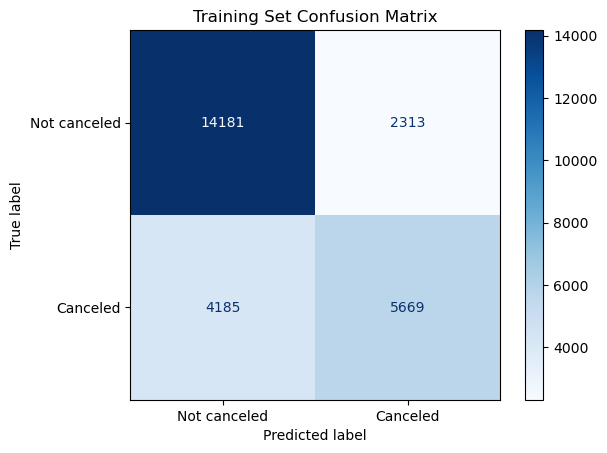

              precision    recall  f1-score   support

Not canceled       0.77      0.86      0.81     16494
    Canceled       0.71      0.58      0.64      9854

    accuracy                           0.75     26348
   macro avg       0.74      0.72      0.72     26348
weighted avg       0.75      0.75      0.75     26348



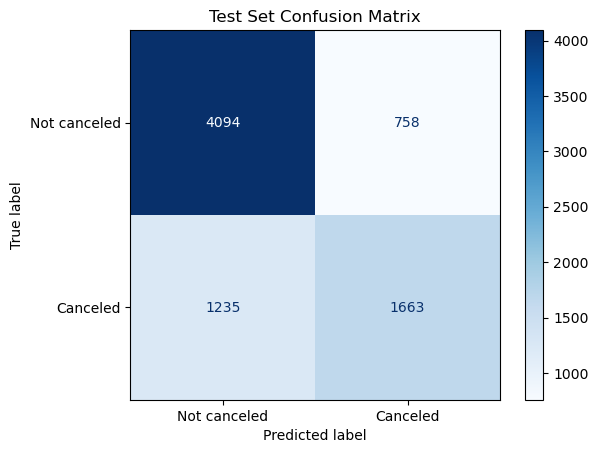

              precision    recall  f1-score   support

Not canceled       0.77      0.84      0.80      4852
    Canceled       0.69      0.57      0.63      2898

    accuracy                           0.74      7750
   macro avg       0.73      0.71      0.71      7750
weighted avg       0.74      0.74      0.74      7750

Training Set ROC AUC: 0.7974686731604574


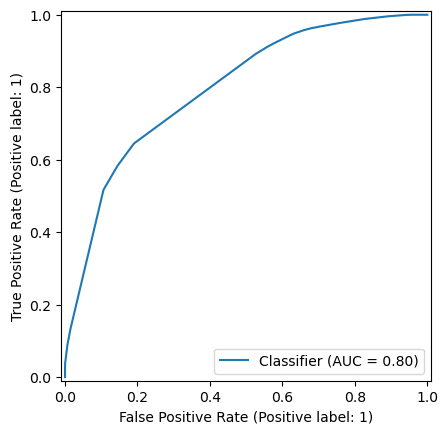

Test Set ROC AUC: 0.7813811242025515


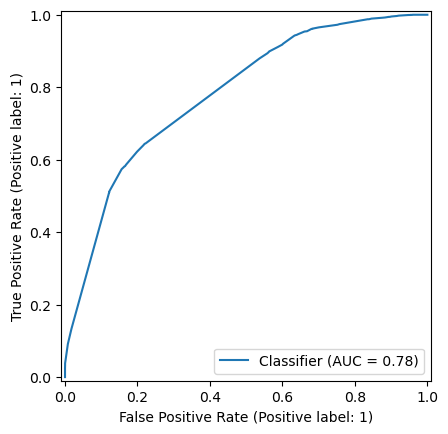

In [6]:
evaluate_model(pipeline_1, X_train, y_train, X_test, y_test)

## Find Best Threshold

Best threshold: 0.48
Best F1: 0.6394115634621964


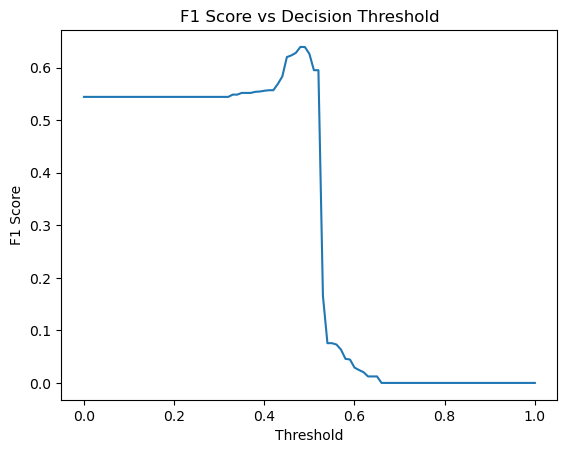

In [7]:
best_threshold = optimal_f1_search(pipeline_1, X_test, y_test)

## Save Train Configs

In [ ]:
segment = "city_hotel_online_ta"
version = "v1"
feature_path = "data/features/cancellation/hotel_market_segment/city_hotel_online_ta_v1"
features_version = "v1"
algorithm = "catboost"
clean_params = {k.replace("model__", ""): v for k, v in search_1.best_params_.items()}
iterations = 5
threshold = float(best_threshold)
pipeline_steps = {
    "validate_schema": True,
    "fill_categorical_missing": True,
    "feature_engineering": True,
    "feature_selection": True,
}

In [ ]:
save_training_config(
    segment, version, feature_path, features_version, algorithm,
    clean_params, iterations, threshold, pipeline_steps
)